# RynnBrain 1.1 Inference Recipes

## Section 7: Contact Point Prediction

This section demonstrates RynnBrain 1.1's ability to predict an instruction-conditioned **contact point** and **in-plane orientation** from an image. The point is represented by `(x, y)` coordinates normalized independently to `[0, 1000]` along the image axes.

The evaluated checkpoint currently serializes the prediction with the legacy tag `<grasp pose> (x, y), theta </grasp pose>`. The recorded test prompts retain the same legacy wording so that each query remains paired with the response it actually produced. In this cookbook, `(x, y)` is interpreted as the predicted contact point and `theta` is visualized as an undirected in-plane axis modulo 180 degrees.

> The fixed-length orientation axis is schematic. It does not represent gripper width, two finger-contact locations, depth, force, collision clearance, kinematic reachability, or physical execution success.

### [Setup] Load examples and visualization utilities

The repository includes eight recorded RynnBrain 1.1 examples so the output contract and visualizations can be inspected without loading the model. The live-inference section later in the notebook uses the same image/query pairs.

In [1]:
from __future__ import annotations

import json
import math
import re
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image


def find_cookbooks_root() -> Path:
    candidates = (Path.cwd(), Path.cwd() / "cookbooks")
    for candidate in candidates:
        if (candidate / "assets" / "contact_point_prediction").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Run this notebook from the repository root or the cookbooks directory."
    )


COOKBOOKS_ROOT = find_cookbooks_root()
ASSET_DIR = COOKBOOKS_ROOT / "assets" / "contact_point_prediction"
TEST_CASES_PATH = ASSET_DIR / "test_cases.json"
RECORDED_RESULTS_PATH = ASSET_DIR / "recorded_results.json"

with RECORDED_RESULTS_PATH.open(encoding="utf-8") as f:
    recorded_results = json.load(f)

print(f"Loaded {len(recorded_results)} recorded examples from {RECORDED_RESULTS_PATH}")

Loaded 8 recorded examples from /Users/sleng/projects/Rynnbrain/RynnBrain/cookbooks/assets/contact_point_prediction/recorded_results.json


In [2]:
NUMBER = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)"
CONTACT_POINT_PATTERN = re.compile(
    rf"<grasp\s+pose>\s*\(\s*(?P<x>{NUMBER})\s*,\s*(?P<y>{NUMBER})\s*\)"
    rf"\s*,\s*(?P<theta>{NUMBER})\s*</grasp\s+pose>",
    re.IGNORECASE,
)


def parse_contact_point_prediction(response: str) -> tuple[float, float, float]:
    match = CONTACT_POINT_PATTERN.search(response)
    if match is None:
        raise ValueError(
            "Expected '<grasp pose> (x, y), theta </grasp pose>' in the model response."
        )

    x = float(match.group("x"))
    y = float(match.group("y"))
    theta = float(match.group("theta"))
    if not all(math.isfinite(value) for value in (x, y, theta)):
        raise ValueError("The predicted coordinates and angle must be finite.")
    if not (0.0 <= x <= 1000.0 and 0.0 <= y <= 1000.0):
        raise ValueError(f"Normalized point ({x}, {y}) is outside [0, 1000].")

    return x, y, theta % 180.0


def normalized_to_pixels(x: float, y: float, image: Image.Image) -> tuple[float, float]:
    width, height = image.size
    return x / 1000.0 * (width - 1), y / 1000.0 * (height - 1)


def draw_contact_point_result(ax, result: dict) -> None:
    image_path = COOKBOOKS_ROOT / result["image"]
    image = Image.open(image_path).convert("RGB")
    x, y, theta = parse_contact_point_prediction(result["pred"])
    x_px, y_px = normalized_to_pixels(x, y, image)

    # Image coordinates use x-right/y-down. The axis length is display-only.
    axis_half_length = 0.13 * min(image.size)
    radians = math.radians(theta)
    dx = math.cos(radians) * axis_half_length
    dy = math.sin(radians) * axis_half_length

    ax.imshow(image)
    ax.plot(
        [x_px - dx, x_px + dx],
        [y_px - dy, y_px + dy],
        color="black",
        linewidth=7,
        alpha=0.75,
        solid_capstyle="round",
    )
    ax.plot(
        [x_px - dx, x_px + dx],
        [y_px - dy, y_px + dy],
        color="#00E5FF",
        linewidth=3,
        linestyle="--",
        solid_capstyle="round",
    )
    ax.scatter(
        [x_px],
        [y_px],
        s=220,
        facecolors="#00E5FF",
        edgecolors="black",
        linewidths=2.5,
        zorder=3,
    )
    ax.set_title(textwrap.fill(result["query"], width=50), fontsize=11, pad=10)
    ax.text(
        0.5,
        0.025,
        f"contact point ({x:g}, {y:g})   |   theta {theta:g} deg",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        color="white",
        fontsize=9.5,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "#07111D",
            "edgecolor": "#00E5FF",
            "alpha": 0.86,
        },
    )
    ax.axis("off")


def show_result_grid(results: list[dict], group: str, title: str) -> None:
    selected = [result for result in results if result["group"] == group]
    fig, axes = plt.subplots(2, 2, figsize=(15, 11), facecolor="white")
    fig.patch.set_alpha(1.0)
    for ax, result in zip(axes.flat, selected):
        ax.set_facecolor("white")
        draw_contact_point_result(ax, result)
    for ax in axes.flat[len(selected):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=17, y=0.995)
    fig.text(
        0.5,
        0.01,
        "Coordinates are normalized independently to [0, 1000]. "
        "The fixed-length axis visualizes orientation only.",
        ha="center",
        fontsize=10,
    )
    plt.tight_layout(rect=(0, 0.04, 1, 0.97), h_pad=2.2, w_pad=1.5)
    plt.show()

### Example 1: Geometry-aware contact-point prediction

These examples cover a thin object, a planar surface, irregular geometry, and a small target. The displayed responses were recorded from the RynnBrain 1.1 inference run and are not ground-truth annotations.

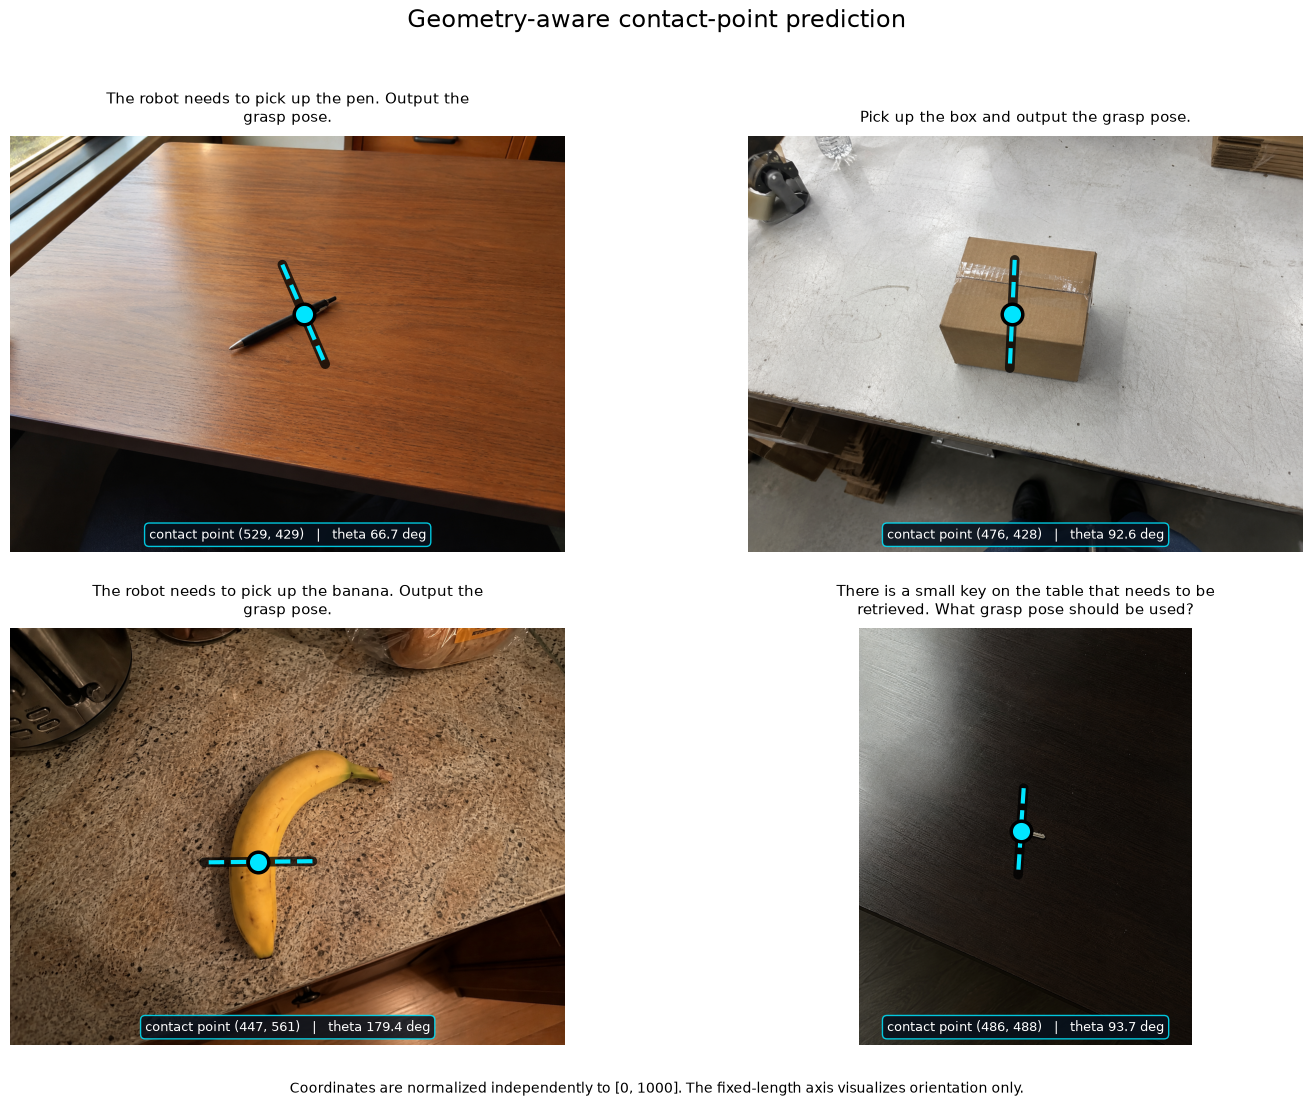

In [3]:
show_result_grid(
    recorded_results,
    group="geometry",
    title="Geometry-aware contact-point prediction",
)

### Example 2: Instruction- and context-aware prediction

These examples test a part-specific instruction, object-state awareness, multi-object referential grounding, and target localization in clutter.

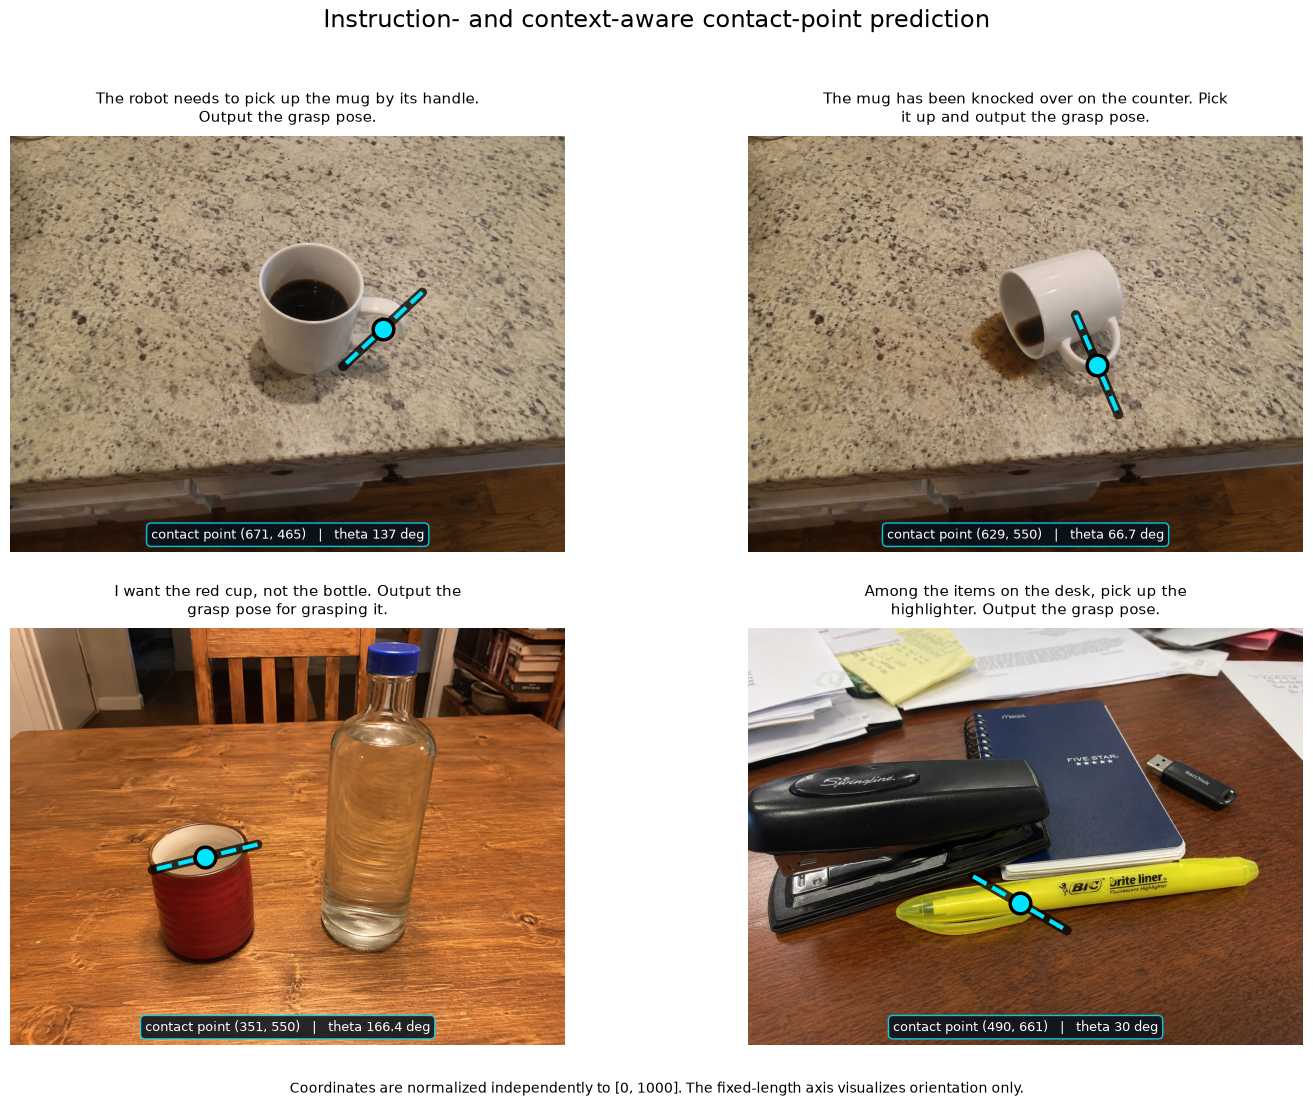

In [4]:
show_result_grid(
    recorded_results,
    group="context",
    title="Instruction- and context-aware contact-point prediction",
)

### [General] Load the RynnBrain 1.1 model and processor

Set `RYNNBRAIN_MODEL_PATH` to the released local or Hub checkpoint before running this section. The 1.1 inference environment used for the recorded examples imports `easy_vlm` **before** `transformers` so that its Qwen3-VL/Qwen3-VL-MoE compatibility patches are registered. Install the release-provided `easy_vlm` runtime before executing the cell.

> Configure any checkpoint authentication outside the notebook with the provider's standard credential mechanism. Never paste access keys into a notebook or commit them to the repository.

In [ ]:
import os

try:
    import easy_vlm  # noqa: F401 -- must patch Qwen3-VL before transformers imports
except ImportError as exc:
    raise ImportError(
        "Install the RynnBrain 1.1 release runtime that provides 'easy_vlm' "
        "before running live inference."
    ) from exc

import torch
from transformers import AutoModelForImageTextToText, AutoProcessor

MODEL_PATH = os.environ.get("RYNNBRAIN_MODEL_PATH", "")
if not MODEL_PATH:
    raise ValueError(
        "Set RYNNBRAIN_MODEL_PATH to the RynnBrain 1.1 checkpoint before running this cell."
    )
if not torch.cuda.is_available():
    raise RuntimeError("This inference recipe requires a CUDA GPU.")

print(f"Loading processor from {MODEL_PATH} ...")
processor = AutoProcessor.from_pretrained(MODEL_PATH)

print(f"Loading model from {MODEL_PATH} ...")
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map={"": "cuda"},
    attn_implementation="flash_attention_2",
)
model.eval()

### Run inference on the eight representative cases

The following helper follows the 1.1 inference script: it sends the original image and natural-language query through the processor chat template, removes prompt tokens from the generated sequence, and decodes only the model response.

In [ ]:
def run_contact_point_inference(case: dict, max_new_tokens: int = 512) -> dict:
    image_path = COOKBOOKS_ROOT / case["image"]
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": str(image_path)},
                {"type": "text", "text": case["query"]},
            ],
        }
    ]

    model_inputs = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to("cuda")

    with torch.no_grad():
        output_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
        )

    output_ids = output_ids[:, model_inputs["input_ids"].size(1):]
    response = processor.decode(output_ids[0], skip_special_tokens=True)
    # Fail early if the checkpoint no longer follows the recorded output contract.
    parse_contact_point_prediction(response)

    return {**case, "pred": response}


In [ ]:
with TEST_CASES_PATH.open(encoding="utf-8") as f:
    test_cases = json.load(f)

results = []
for index, case in enumerate(test_cases, start=1):
    print(f"[{index}/{len(test_cases)}] {case['image_name']}: {case['query']}")
    result = run_contact_point_inference(case)
    print(f"  {result['pred']}")
    results.append(result)

output_path = COOKBOOKS_ROOT / "contact_point_prediction_results.json"
with output_path.open("w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"Saved {len(results)} results to {output_path}")

In [ ]:
show_result_grid(
    results,
    group="geometry",
    title="Live results: geometry-aware prediction",
)
show_result_grid(
    results,
    group="context",
    title="Live results: instruction- and context-aware prediction",
)

### Summary

This cookbook demonstrates instruction-conditioned contact-point prediction across complementary geometry and context cases. It:

- parses one normalized contact point `(x, y)` and one in-plane orientation `theta`;
- maps each coordinate independently from `[0, 1000]` to the image dimensions;
- covers thin, planar, irregular, and small objects;
- tests part constraints, object state, referential grounding, and clutter; and
- visualizes the reported orientation without claiming gripper width or physical execution success.

The recorded responses are model outputs, not ground-truth grasp annotations. A downstream robot system must still account for depth, collision checking, reachability, gripper geometry, and closed-loop execution.